# Classification Challenge

Wine experts can identify wines from specific vineyards through smell and taste, but the factors that give different wines their individual charateristics are actually based on their chemical composition.

In this challenge, you must train a classification model to analyze the chemical and visual features of wine samples and classify them based on their cultivar (grape variety).

> **Citation**: The data used in this exercise was originally collected by Forina, M. et al.
>
> PARVUS - An Extendible Package for Data Exploration, Classification and Correlation.
Institute of Pharmaceutical and Food Analysis and Technologies, Via Brigata Salerno,
16147 Genoa, Italy.
>
> It can be downloaded from the UCI dataset repository (Dua, D. and Graff, C. (2019). [UCI Machine Learning Repository]([http://archive.ics.uci.edu/ml). Irvine, CA: University of California, School of Information and Computer Science). 

## Explore the data

Run the following cell to load a CSV file of wine data, which consists of 12 numeric features and a classification label with the following classes:

- **0** (*variety A*)
- **1** (*variety B*)
- **2** (*variety C*)

In [1]:
import pandas as pd
data = pd.read_csv('data/wine.csv')
sample = data.sample(5)
sample

,Alcohol,Malic_acid,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color_intensity,Hue,OD280_315_of_diluted_wines,Proline,WineVariety
58,13.72,1.43,2.50,16.7,108,3.40,3.67,0.19,2.04,6.80,0.89,2.87,1285,0
7,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295,0
73,12.99,1.67,2.60,30.0,139,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985,1
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,2
129,12.04,4.30,2.38,22.0,80,2.10,1.75,0.42,1.35,2.60,0.79,2.57,580,1


Your challenge is to explore the data and train a classification model that achieves an overall *Recall* metric of over 0.95 (95%).

> **Note**: There is no single "correct" solution. A sample solution is provided in [03 - Wine Classification Solution.ipynb](03%20-%20Wine%20Classification%20Solution.ipynb).

## Train and evaluate a model

Add markdown and code cells as required to to explore the data, train a model, and evaluate the model's predictive performance.

In [2]:
wine_classes = ['variety A', 'variety B', 'variety C']
print(list(sample.columns[0:3].values+ sample.columns[-1]), 'WineClasses')

#for index, row in sample.iterrows():
   # print('[', row[0], row[1], row[2], int(row[-1]), ']', wine_classes[int(row[-1])])

for row in sample.iloc:
    print('[', row.iloc[0], row.iloc[1], row.iloc[2], int(row.iloc[-1]), ']', wine_classes[int(row.iloc[-1])])
    

['AlcoholWineVariety', 'Malic_acidWineVariety', 'AshWineVariety'] WineClasses
[ 13.72 1.43 2.5 0 ] variety A
[ 14.06 2.15 2.61 0 ] variety A
[ 12.99 1.67 2.6 1 ] variety B
[ 13.71 5.65 2.45 2 ] variety C
[ 12.04 4.3 2.38 1 ] variety B


### Separate features and label

In [3]:
wine_features = ['Alcohol','Malic_acid','Ash','Alcalinity','Magnesium','Phenols','Flavanoids','Nonflavanoids','Proanthocyanins','Color_intensity','Hue','OD280_315_of_diluted_wines','Proline']
wine_label = 'WineVariety'
X, y = data[wine_features].values, data[wine_label].values

for n in range(0,4):
    print("Wine", str(n+1), "\n  Features:",list(X[n]), "\n  Label:", y[n])

Wine 1 
  Features: [14.23, 1.71, 2.43, 15.6, 127.0, 2.8, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065.0] 
  Label: 0
Wine 2 
  Features: [13.2, 1.78, 2.14, 11.2, 100.0, 2.65, 2.76, 0.26, 1.28, 4.38, 1.05, 3.4, 1050.0] 
  Label: 0
Wine 3 
  Features: [13.16, 2.36, 2.67, 18.6, 101.0, 2.8, 3.24, 0.3, 2.81, 5.68, 1.03, 3.17, 1185.0] 
  Label: 0
Wine 4 
  Features: [14.37, 1.95, 2.5, 16.8, 113.0, 3.85, 3.49, 0.24, 2.18, 7.8, 0.86, 3.45, 1480.0] 
  Label: 0


In [4]:
# Count the number of null values for each column
data.isnull().sum()

# Show rows containing nulls
# data[data.isnull().any(axis=1)]

Alcohol                       0
Malic_acid                    0
Ash                           0
Alcalinity                    0
Magnesium                     0
Phenols                       0
Flavanoids                    0
Nonflavanoids                 0
Proanthocyanins               0
Color_intensity               0
Hue                           0
OD280_315_of_diluted_wines    0
Proline                       0
WineVariety                   0
dtype: int64

### Compare feature distributions

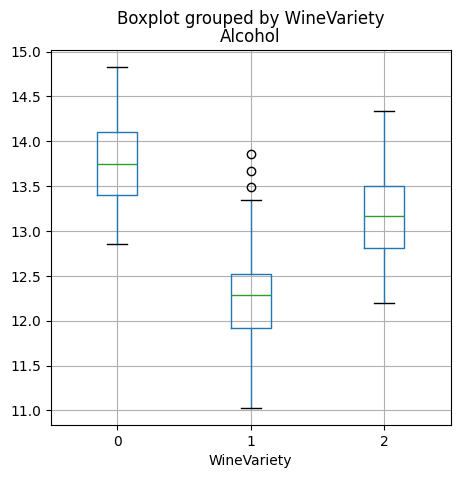

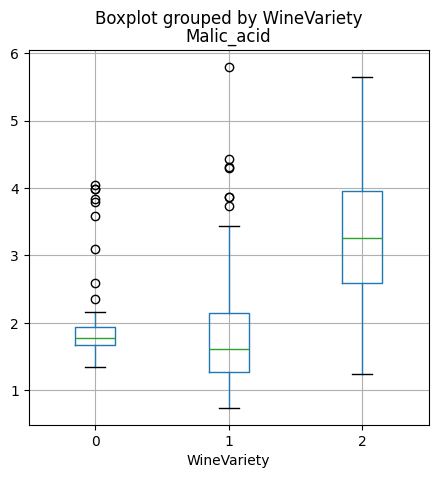

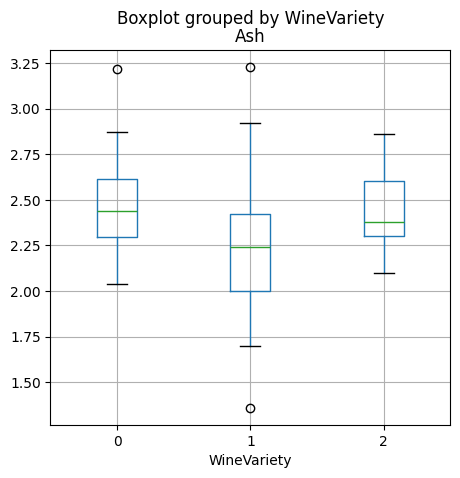

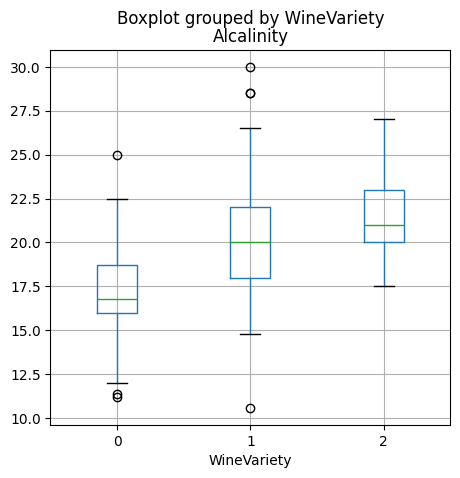

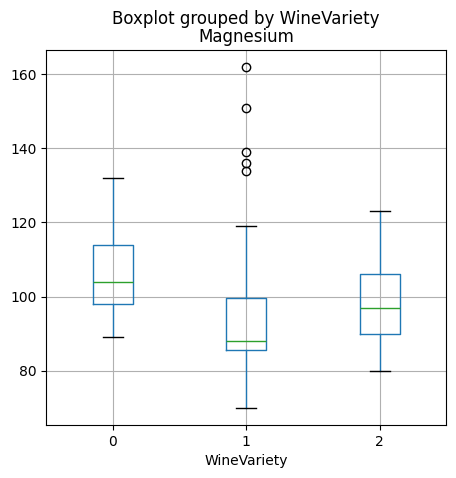

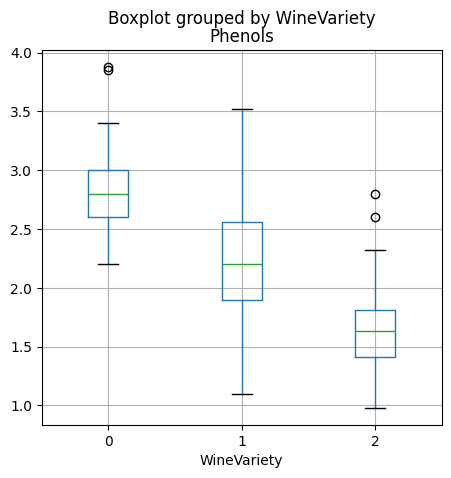

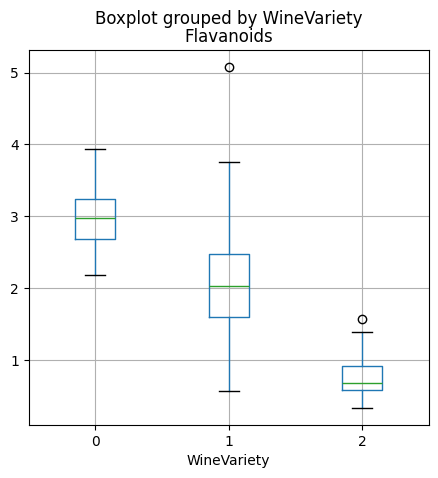

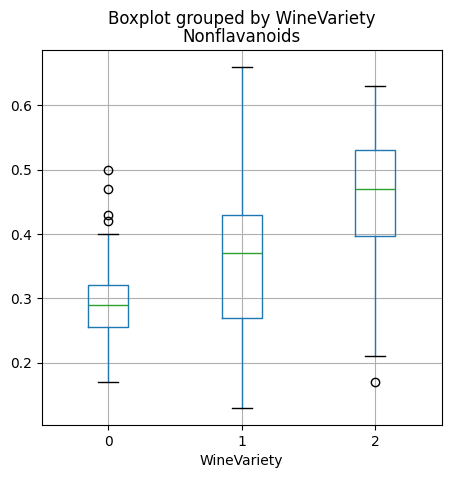

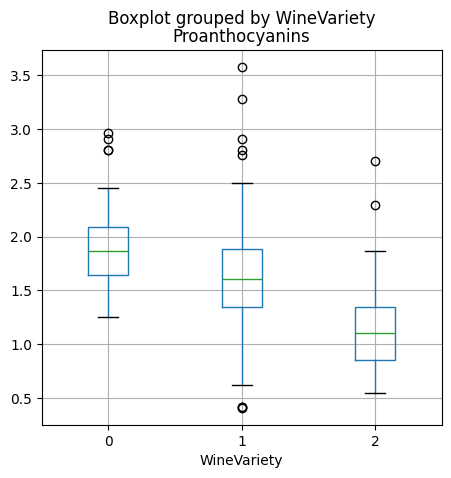

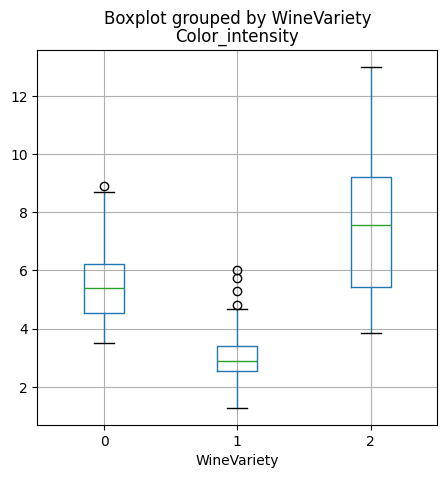

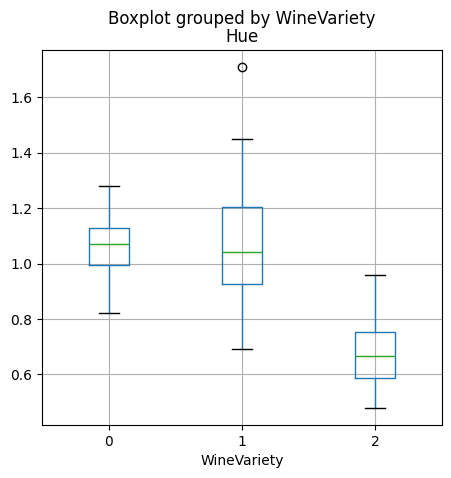

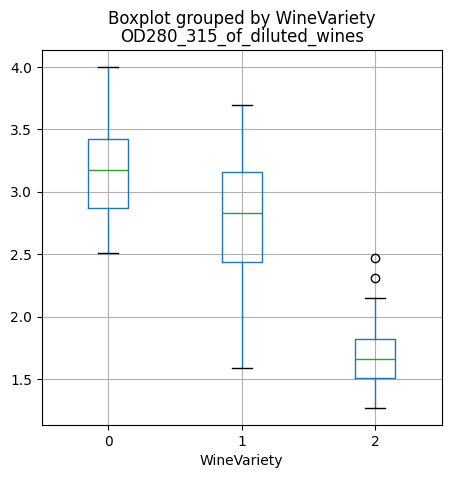

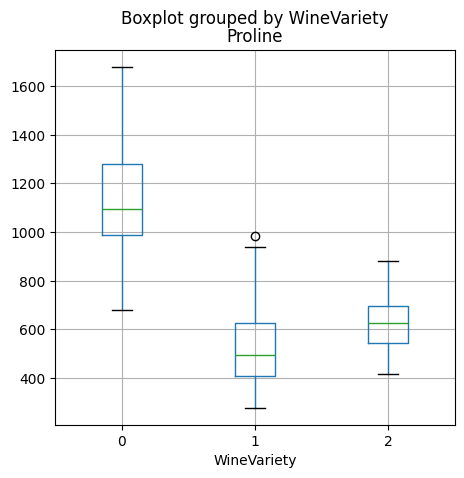

In [5]:
from matplotlib import pyplot as plt
%matplotlib inline

for col in wine_features:
    data.boxplot(column= col, by= wine_label, figsize = (5,5))
    plt.title(col)

plt.show()


### Split the data for training and validation

In [6]:
from sklearn.model_selection import train_test_split

wine_X, wine_y = data[wine_features].values, data[wine_label].values
x_wine_train, x_wine_test, y_wine_train, y_wine_test = train_test_split(wine_X, wine_y, test_size = 0.30, random_state = 0, stratify = wine_y) 

print ('Training Set: %d\nTest Set: %d \n' % (x_wine_train.shape[0], x_wine_test.shape[0]))

Training Set: 124
Test Set: 54 



### Normalize features and train model

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Define preprocessing for numeric columns (scale them)
feature_columns = [0,1,2,3,4,5,6]
feature_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
    ])

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('preprocess', feature_transformer, feature_columns)])

# Create training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', LogisticRegression(solver='lbfgs'))])

wine_model1 = pipeline.fit(x_wine_train, y_wine_train)
print(wine_model1 )

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('preprocess',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6])])),
                ('regressor', LogisticRegression())])


### Evaluate Model

Overall Accuracy: 0.9629629629629629
Overall Precision: 0.9710144927536232
Overall Recall: 0.9592592592592593
[[17  1  0]
 [ 0 21  0]
 [ 0  1 14]]


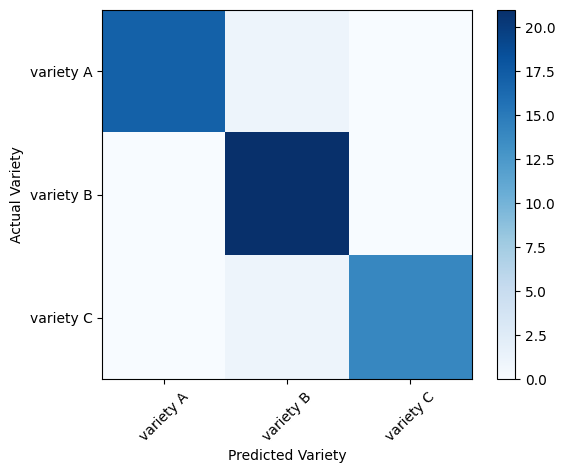

In [8]:
from sklearn. metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# Get predictions from test data
wine_predictions1 = wine_model1.predict(x_wine_test)

# Get metrics
print("Overall Accuracy:",accuracy_score(y_wine_test, wine_predictions1))
print("Overall Precision:",precision_score(y_wine_test, wine_predictions1, average='macro'))
print("Overall Recall:",recall_score(y_wine_test, wine_predictions1, average='macro'))

# Print confusion matrix
mcm = confusion_matrix(y_wine_test, wine_predictions1)
print(mcm)


# Plot confusion matrix
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(wine_classes))
plt.xticks(tick_marks, wine_classes, rotation=45)
plt.yticks(tick_marks, wine_classes)
plt.xlabel("Predicted Variety")
plt.ylabel("Actual Variety")
plt.show()

Average AUC: 0.9984681984681986


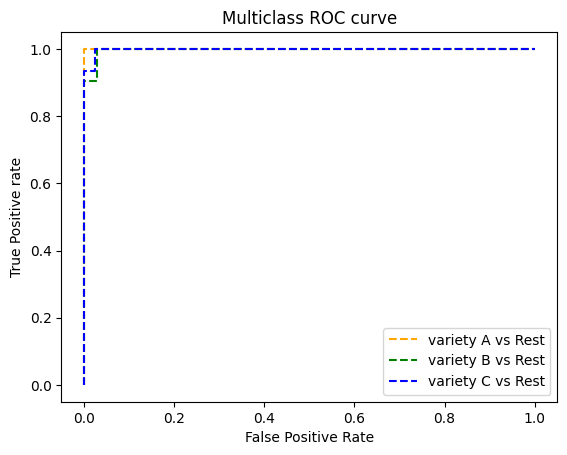

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get class probability scores
wine_prob = wine_model1.predict_proba(x_wine_test)

auc = roc_auc_score(y_wine_test,wine_prob, multi_class='ovr')
print('Average AUC:', auc)

# Get ROC metrics for each class
fpr = {}
tpr = {}
thresh ={}
for i in range(len(wine_classes)):    
    fpr[i], tpr[i], thresh[i] = roc_curve(y_wine_test, wine_prob[:,i], pos_label=i)
    
# Plot the ROC chart
plt.plot(fpr[0], tpr[0], linestyle='--',color='orange', label=wine_classes[0] + ' vs Rest')
plt.plot(fpr[1], tpr[1], linestyle='--',color='green', label=wine_classes[1] + ' vs Rest')
plt.plot(fpr[2], tpr[2], linestyle='--',color='blue', label=wine_classes[2] + ' vs Rest')
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.show()

## Use the model with new data observation

When you're happy with your model's predictive performance, save it and then use it to predict classes for the following two new wine samples:

- \[13.72,1.43,2.5,16.7,108,3.4,3.67,0.19,2.04,6.8,0.89,2.87,1285\]
- \[12.37,0.94,1.36,10.6,88,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520\]


In [10]:
import joblib

filename = './wine_classifier.pkl'
joblib.dump(wien)
x_new = np.array ([[13.72,1.43,2.5,16.7,108,3.4,3.67,0.19,2.04,6.8,0.89,2.87,1285], 
                  [12.37,0.94,1.36,10.6,88,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520]])

predictions= wine_model1.predict(x_new)

for prediction in predictions:
    print(prediction, '(' + wine_classes[prediction] +')' )

0 (variety A)
1 (variety B)
